### I. Basic Import

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd
from statsmodels.stats.diagnostic import lilliefors
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif, RFECV
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS

### II. Dataset Loading and its Structure

In [40]:
path = os.path.join(os.getcwd(), 'model', 'data', 'creditcard.csv')
data_str = np.loadtxt(path, delimiter=',', dtype=str, skiprows=0)
data_num = np.loadtxt(path, delimiter=',', skiprows=1, usecols=range(30))
data_gen = np.genfromtxt(path, delimiter=',', dtype=None, names=True)

In [39]:
data_gen.shape

(284807,)

In [3]:
data = np.genfromtxt(path, delimiter=',', dtype=None)

In [4]:
data_gen['Time'][0]

np.float64(0.0)

In [5]:
data_str.shape, data_gen.shape, data.shape

((284808, 31), (284807,), (284808, 31))

In [6]:
data1 = data[1:]

In [7]:
data_gen[0]

np.void((0.0, -1.3598071336738, -0.0727811733098497, 2.53634673796914, 1.37815522427443, -0.338320769942518, 0.462387777762292, 0.239598554061257, 0.0986979012610507, 0.363786969611213, 0.0907941719789316, -0.551599533260813, -0.617800855762348, -0.991389847235408, -0.311169353699879, 1.46817697209427, -0.470400525259478, 0.207971241929242, 0.0257905801985591, 0.403992960255733, 0.251412098239705, -0.018306777944153, 0.277837575558899, -0.110473910188767, 0.0669280749146731, 0.128539358273528, -0.189114843888824, 0.133558376740387, -0.0210530534538215, 149.62, '"0"'), dtype=[('Time', '<f8'), ('V1', '<f8'), ('V2', '<f8'), ('V3', '<f8'), ('V4', '<f8'), ('V5', '<f8'), ('V6', '<f8'), ('V7', '<f8'), ('V8', '<f8'), ('V9', '<f8'), ('V10', '<f8'), ('V11', '<f8'), ('V12', '<f8'), ('V13', '<f8'), ('V14', '<f8'), ('V15', '<f8'), ('V16', '<f8'), ('V17', '<f8'), ('V18', '<f8'), ('V19', '<f8'), ('V20', '<f8'), ('V21', '<f8'), ('V22', '<f8'), ('V23', '<f8'), ('V24', '<f8'), ('V25', '<f8'), ('V26', '<

In [8]:
data[0]

array(['"Time"', '"V1"', '"V2"', '"V3"', '"V4"', '"V5"', '"V6"', '"V7"',
       '"V8"', '"V9"', '"V10"', '"V11"', '"V12"', '"V13"', '"V14"',
       '"V15"', '"V16"', '"V17"', '"V18"', '"V19"', '"V20"', '"V21"',
       '"V22"', '"V23"', '"V24"', '"V25"', '"V26"', '"V27"', '"V28"',
       '"Amount"', '"Class"'], dtype='<U21')

In [9]:
data1[0]

array(['0', '-1.3598071336738', '-0.0727811733098497', '2.53634673796914',
       '1.37815522427443', '-0.338320769942518', '0.462387777762292',
       '0.239598554061257', '0.0986979012610507', '0.363786969611213',
       '0.0907941719789316', '-0.551599533260813', '-0.617800855762348',
       '-0.991389847235408', '-0.311169353699879', '1.46817697209427',
       '-0.470400525259478', '0.207971241929242', '0.0257905801985591',
       '0.403992960255733', '0.251412098239705', '-0.018306777944153',
       '0.277837575558899', '-0.110473910188767', '0.0669280749146731',
       '0.128539358273528', '-0.189114843888824', '0.133558376740387',
       '-0.0210530534538215', '149.62', '"0"'], dtype='<U21')

In [10]:
data_gen['Time']

array([0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.72788e+05,
       1.72788e+05, 1.72792e+05], shape=(284807,))

In [11]:
data[:, 0]

array(['"Time"', '0', '0', ..., '172788', '172788', '172792'],
      shape=(284808,), dtype='<U21')

There are 31 columns in this dataset, they are not well formatting. So, I loaded the dataset by skipping the last column.
We essentially have:
- **quantitative variables** : *Time* for the first column, and 28 numerical variables resulting from Principal Component Analysis
- **a qualitative variable**: which is the output, representing whether or not the transaction is normal
In this dataset, we can see there are no missing values.

In [12]:
_, unique_indices = np.unique(data_str, axis=0, return_index=True)

In [14]:
unique_indices

array([     0,      1,      2, ..., 153756, 153757, 153758],
      shape=(283727,))

In [15]:
_, unique_indices1 = np.unique(data1, axis=0, return_index=True)

In [16]:
unique_indices, unique_indices1

(array([     0,      1,      2, ..., 153756, 153757, 153758],
       shape=(283727,)),
 array([     0,      1,      3, ..., 153755, 153756, 153757],
       shape=(283726,)))

In [43]:
_, unique_indices3 = np.unique(data_num, axis=0, return_index=True)

In [44]:
data_str_clean = data_str[unique_indices, :]
data_num_clean = data_num[unique_indices3, :]  
data1_clean = data1[unique_indices1, :]

In [18]:
np.sum(data_str_clean[:, 30] == '"0"'), np.sum(data1_clean[:, 30] == '"0"')

(np.int64(283253), np.int64(283253))

In [19]:
np.sum(data_str_clean[:, 30] == '"1"'), np.sum(data1_clean[:, 30] == '"1"')

(np.int64(473), np.int64(473))

In [73]:
y = np.zeros(data_str.shape[0])
y_mask1 = data_str[:, 30] == '"1"'
y[y_mask1] = 1
y_clean = y[unique_indices][1:]

In [74]:
y_clean.shape

(283726,)

In [75]:
y1 = np.zeros(data1.shape[0])
y_mask01 = data1[:, 30] == '"1"'
y1[y_mask01] = 1
y_clean1 = y1[unique_indices1]

In [76]:
y_clean1.shape

(283726,)

We notice there are repeated rows and we removed them.
In the new dataset (clean), there are now 283726 unique rows: 283 253 normal transactions and 473 labeled as frauds.

### III. Univariate Analysis

Among quantitative variables, we will only focus on *'Time'* and *'Amount'* variables since the 28 other variables are the results of PCA and they are not meaningful for us.

#### About Time

Feature *'Time'* contains the seconds elapsed between each transaction and the first transaction in the dataset

In [22]:
#time_array = data_num_clean[:, 0]

In [23]:
time_array1 = data1_clean[:, 0]

In [24]:
time_array1.shape

(283726,)

In [25]:
time_array2 = time_array1.astype(float)

In [26]:
time_array2.shape

(283726,)

In [27]:
np.mean(time_array2), np.median(time_array2), stats.mode(time_array2)

(np.float64(94811.07759951502),
 np.float64(84692.5),
 ModeResult(mode=np.float64(3767.0), count=np.int64(21)))

In [29]:
np.mean(time_array2), np.median(time_array2), stats.mode(time_array2)

(np.float64(94811.07759951502),
 np.float64(84692.5),
 ModeResult(mode=np.float64(3767.0), count=np.int64(21)))

In [30]:
np.min(time_array2), np.max(time_array2), np.std(time_array2, ddof=1)

(np.float64(0.0), np.float64(172792.0), np.float64(47481.047890619506))

In [31]:
np.quantile(time_array2, 0.25), np.quantile(time_array2, 0.75)

(np.float64(54204.75), np.float64(139298.0))

In [32]:
iqr_time = np.quantile(time_array2, 0.75) - np.quantile(time_array2, 0.25)
time_lower_bound = np.quantile(time_array2, 0.25) - 1.5 * iqr_time
time_upper_bound = np.quantile(time_array2, 0.75) + 1.5 * iqr_time
time_outliers_mask = (time_array2 < time_lower_bound) | (time_array2 > time_upper_bound)
time_outliers = time_array2[time_outliers_mask]
time_outliers.shape

(0,)

<Figure size 640x480 with 0 Axes>

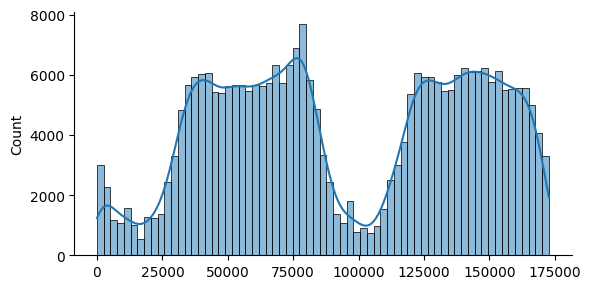

In [33]:
fig = plt.figure()
sns.displot(time_array2, kde=True, height=3, aspect=2)
plt.show()

For *'time'* variable, there is zero potential outlier. Its distribution is largely bimodal, it seems it is because transactions occurred during two days and they appear to be seasonal.

#### About Amount

In [45]:
amount_array = data_num_clean[:, 29]

In [46]:
np.mean(amount_array), np.median(amount_array), stats.mode(amount_array)

(np.float64(88.47268731099723),
 np.float64(22.0),
 ModeResult(mode=np.float64(1.0), count=np.int64(13566)))

In [47]:
np.min(amount_array), np.max(amount_array), np.std(amount_array, ddof=1)

(np.float64(0.0), np.float64(25691.16), np.float64(250.39943711577334))

In [48]:
np.quantile(amount_array, 0.25), np.quantile(amount_array, 0.75)

(np.float64(5.6), np.float64(77.51))

In [49]:
iqr_amount = np.quantile(amount_array, 0.75) - np.quantile(amount_array, 0.25)
amount_lower_bound = np.quantile(amount_array, 0.25) - 1.5 * iqr_amount
amount_upper_bound = np.quantile(amount_array, 0.75) + 1.5 * iqr_amount
amount_outliers_mask = (amount_array < amount_lower_bound) | (amount_array > amount_upper_bound)
amount_outliers = amount_array[amount_outliers_mask]
amount_outliers.shape

(31685,)

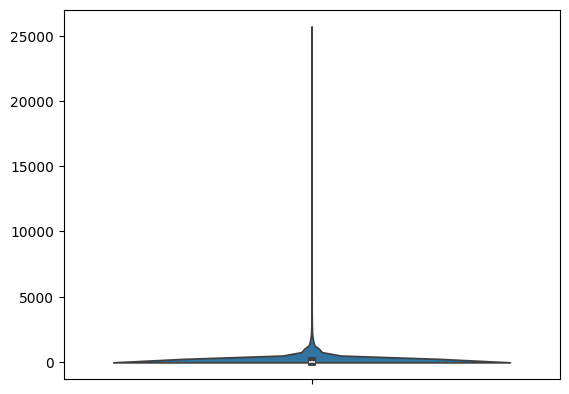

In [50]:
plt.figure()
sns.violinplot(y=amount_array)
plt.show()

*'Amount'* distribution is very narrow with a right-asymmetry as we can see with the mean larger than the median. On a total of 283726 rows, there are 31685 potential outliers. But since in the dataset, there are only 473 labeled as frauds, it seems difficult to attribuate thesee outliers as frauds.

### IV. Bivariate Analysis

One goal of bivariate analysis could be features selection. Here, we want to know how each variable could explain how to distinguish normal transactions from frauds.

In [56]:
fraud_mask = np.where(data_str_clean[:, 30] == '"1"')[0] - 1
normal_mask = np.where(data_str_clean[:, 30] == '"0"')[0] - 1
fraud_mask.shape, normal_mask.shape

((473,), (283253,))

In [57]:
data_num_clean.shape, data_str_clean.shape

((283726, 30), (283727, 31))

In [58]:
data_num_clean[fraud_mask, :].shape, data_num_clean[normal_mask, :].shape

((473, 30), (283253, 30))

In [59]:
def shapiro_t(data, alpha):
    return stats.shapiro(data)[1] > alpha

def ks_t(data, alpha):
    return stats.kstest(data, 'norm')[1] > alpha

def dagostino_t(data, alpha):
    return stats.normaltest(data)[1] > alpha

def lilliefors_t(data, alpha):
    return lilliefors(data)[1] > alpha

In [60]:
shapiro_fraud = np.zeros(data_num_clean.shape[1])
shapiro_normal = np.zeros(data_num_clean.shape[1])
ks_fraud = np.zeros(data_num_clean.shape[1])
ks_normal = np.zeros(data_num_clean.shape[1])
dagostino_fraud = np.zeros(data_num_clean.shape[1])
dagostino_normal = np.zeros(data_num_clean.shape[1])
lilliefors_fraud = np.zeros(data_num_clean.shape[1])
lilliefors_normal = np.zeros(data_num_clean.shape[1])
f_std = np.zeros(data_num_clean.shape[1])
n_std = np.zeros(data_num_clean.shape[1])
student_p = np.zeros(data_num_clean.shape[1])
welch_p = np.zeros(data_num_clean.shape[1])
mann_whitn_p = np.zeros(data_num_clean.shape[1])

In [61]:
alpha = 0.05

for i in range(data_num_clean.shape[1]):
    fraud_data = data_num_clean[fraud_mask, i]
    normal_data = data_num_clean[normal_mask, i]
    fraud_std = np.std(fraud_data, ddof=1)
    normal_std = np.std(normal_data, ddof=1)


    fraud_shapiro = shapiro_t(fraud_data, alpha)
    normal_shapiro = shapiro_t(normal_data, alpha)

    fraud_ks = ks_t(fraud_data, alpha)
    normal_ks = ks_t(normal_data, alpha)

    fraud_dagostino = dagostino_t(fraud_data, alpha)
    normal_dagostino = dagostino_t(normal_data, alpha)  

    fraud_lilliefors = lilliefors_t(fraud_data, alpha)
    normal_lilliefors = lilliefors_t(normal_data, alpha)


    shapiro_fraud[i] = fraud_shapiro
    shapiro_normal[i] = normal_shapiro
    ks_fraud[i] = fraud_ks
    ks_normal[i] = normal_ks
    dagostino_fraud[i] = fraud_dagostino
    dagostino_normal[i] = normal_dagostino
    lilliefors_fraud[i] = fraud_lilliefors
    lilliefors_normal[i] = normal_lilliefors
    f_std[i] = fraud_std
    n_std[i] = normal_std
    student_p[i] = stats.ttest_ind(fraud_data, normal_data, equal_var=True)[1]
    welch_p[i] = stats.ttest_ind(fraud_data, normal_data, equal_var=False)[1]
    mann_whitn_p[i] = stats.mannwhitneyu(fraud_data, normal_data)[1]

c:\Users\tapib\OneDrive\Desktop\Will\w_Data\data_env\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 283253.
  res = hypotest_fun_out(*samples, **kwds)


In [62]:
test_results = pd.DataFrame({
    'Shapiro Fraud': shapiro_fraud,
    'Shapiro Normal': shapiro_normal,
    'KS Fraud': ks_fraud,
    'KS Normal': ks_normal,
    'D\'Agostino Fraud': dagostino_fraud,
    'D\'Agostino Normal': dagostino_normal,
    'Lilliefors Fraud': lilliefors_fraud,
    'Lilliefors Normal': lilliefors_normal,
    'Std Fraud': f_std,
    'Std Normal': n_std,
    'Student p-value': student_p,
    'Welch p-value': welch_p,
    'Mann-Whitney p-value': mann_whitn_p
})

In [63]:
test_results

,Shapiro Fraud,Shapiro Normal,KS Fraud,KS Normal,D'Agostino Fraud,D'Agostino Normal,Lilliefors Fraud,Lilliefors Normal,Std Fraud,Std Normal,Student p-value,Welch p-value,Mann-Whitney p-value
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49625.171936,47476.797531,0.004382,0.006641,0.001072
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.817925,1.948238,0.534369,0.505903,0.481575
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.450303,1.647010,0.249735,0.192000,0.225155
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.381467,1.508884,0.271770,0.230736,0.081104
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.302081,1.414364,0.353579,0.314263,0.451696
5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.519120,1.376759,0.304810,0.352681,0.227053
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.392518,1.331829,0.764530,0.774601,0.601810
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.289928,1.227556,0.220738,0.244382,0.045295
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.429495,1.178594,0.514761,0.591204,0.179273
9,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.034256,1.095593,0.622750,0.602587,0.783717


It appears that we don't have normal distributions trough our data set variables. At a significance level of 0.05 all variables could be used to explain the differences between normal bank transaction and fraud.

### V. Features Selection

We want to identify the most relevant variables for our goal of distinguishing normal banking transactions from fraudulent ones, and this should be the smallest set of variables.
Although this is not stricly necessary for statistical testing, for the next I will normalize the variables to ensure that features selection is not biased by the scale of the different variables, thereby ensuring scalability.

In [64]:
scaler = RobustScaler(unit_variance=True)
data_num_scaled = scaler.fit_transform(data_num_clean)
data_num_scaled.shape, data_num_clean.shape

((283726, 30), (283726, 30))

#### Based on Variance

In [65]:
variances = np.var(data_num_scaled, axis=0)
sorted_variance_indices = np.argsort(variances)[::-1]
sorted_variance_indices

array([29, 28, 27, 20,  8, 23, 21,  2,  6,  7, 10,  5, 14, 12, 17,  4, 19,
        9, 16,  1, 26, 18,  3, 25, 24, 13, 15, 11, 22,  0])

#### Using VarianceThreshold

In [66]:
threshold = 1.5
variance_selector = VarianceThreshold(threshold=threshold)
high_variance_features = variance_selector.fit_transform(data_num_scaled)
np.where(variance_selector.get_support())

(array([ 2,  5,  6,  7,  8, 10, 12, 14, 17, 20, 21, 23, 27, 28, 29]),)

#### Using SelectKBest

In [77]:
kbest_selector = SelectKBest(score_func=mutual_info_classif, k='all')
kbest_data_num_scaled = kbest_selector.fit_transform(data_num_scaled, y_clean)
kbest_scores = kbest_selector.scores_

In [79]:
kbest_sorted_indices = np.argsort(kbest_scores)[::-1]
kbest_sorted_indices[0:15]

array([ 0, 16, 25, 19, 22,  8,  3, 17,  4,  9, 24, 11,  7, 26, 28])

#### Forward Selection

In [80]:
X_train, X_test, y_train, y_test = train_test_split(data_num_scaled, y_clean, 
                                                    test_size=0.2, random_state=7, 
                                                    stratify=y_clean)
clf = LogisticRegression(solver='liblinear', max_iter=100)

In [81]:
sfs = SFS(clf, k_features='best', forward=True, floating=False, scoring='accuracy', cv=5)
sfs = sfs.fit(X_train, y_train)

In [82]:
sfs.k_score_

np.float64(0.998334655035686)

In [84]:
#print(sfs.k_feature_idx_)

#### Backward Selection

In [ ]:
sbs = SFS(clf, k_features='best', forward=False, floating=False, scoring='accuracy', cv=5)
sbs = sbs.fit(X_train, y_train)

In [ ]:
sbs.k_score_

In [ ]:
print(sbs.k_feature_idx_)

#### Recursive Feature Elimination

In [ ]:
rfe = RFECV(clf, step=1, cv=5, scoring='accuracy')
rfe = rfe.fit(X_train, y_train)

In [ ]:
rfe.cv_results_['mean_test_score'].max()

In [ ]:
np.where(rfe.support_)

It seems difficult to choose certain features over others. We have indeed seen that each of them provides a significant explanation for the difference between normal and fraudulent transactions. The procedures used to select features barely manage to favor certain features over others, and we can see that the algorithms used perform very well.